# DFG manuscript plots

In [1]:

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 25


In [ ]:

from scipy.spatial import Delaunay
#import polyscope as ps


from lsm import HNdC_ijk

# ddg imports
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from hyperct import *
from ddgclib._sphere import *


def distance(a, b):
    return np.linalg.norm(a - b)

def circumcenter(vertices):
    A, B, C = vertices
    a = distance(B, C)
    b = distance(C, A)
    c = distance(A, B)

    if a == 0 or b == 0 or c == 0:
        raise ValueError("Invalid triangle: degenerate or duplicate vertices")

    # Calculate the circumradius
    s = (a + b + c) / 2
    area = np.sqrt(s * (s - a) * (s - b) * (s - c))
    circumradius = (a * b * c) / (4 * area)

    # Calculate the normalized barycentric coordinates
    alpha = (a * a * (b * b + c * c - a * a)) / (a * a + b * b + c * c)
    beta = (b * b * (c * c + a * a - b * b)) / (a * a + b * b + c * c)
    gamma = (c * c * (a * a + b * b - c * c)) / (a * a + b * b + c * c)

    circumcenter = (alpha * A + beta * B + gamma * C) / (alpha + beta + gamma)

    return circumcenter

# Example usage
#triangle_vertices = np.array([[1, 2, 0], [4, 0, 1], [0, 0, 5]], dtype=np.float64)
#print("Circumcenter:", circumcenter(triangle_vertices))


# Write a function that builds a dual cache called HC.Vd,
# each member of the `Vd` set should be connect only to primal
# vertices in HC.V

#dist = np.linalg.norm(v.x_a - v2.x_a)
#            if dist < cdist:
        
def compute_vd(HC, cdist =1e-10):
    """
    Computes the dual vertices of a primal vertex cache HC.V on
    each dim - 1 simplex.
    
    Currently only dim = 2 is supported
    
    cdist: float, tolerance for where a unique dual vertex can exist
    
    """
    # Construct dual cache
    HC.Vd = VertexCacheField() 
    
    # Construct dual neighbour sets
    for v in HC.V:
        v.vd = set()
            
    #hcv = copy.copy(HC.V)        
    for v1 in HC.V:
        for v2 in v1.nn:
            # Find all v2.nn also connected to v1:
            v1nn_u_v2nn = v1.nn.intersection(v2.nn)
            for v3 in v1nn_u_v2nn:
                # TODO: Re-implement cache:
                verts = np.zeros([3, 2])
                verts[0] = v1.x_a
                verts[1] = v2.x_a
                verts[2] = v3.x_a
                # Compute the circumcentre:
                cd = circumcenter(verts)
                # Note instead of below, could round off cd in general to say nearest 1e-12
                # Check for uniqueness first (new, expensive, could 
                # be improved by checking duals of neighbours only?):
                for vd_i in HC.Vd:
                    dist = np.linalg.norm(vd_i.x_a - cd)
                    if dist < cdist:
                        cd = vd_i.x_a
                        
                vd = HC.Vd[tuple(cd)]
                # Connect to all primal vertices
                for v in [v1, v2, v3]:
                    v.vd.add(vd)
                    vd.nn.add(v)
                    
    return HC  # self


# Find the Delaunay dual
def triang_dual(points, plot_delaunay=False):
    """
    Compute the Delaunay triangulation plus the dual points. Put into hyperct complex object.
    
    """
    tri = Delaunay(points)
    if plot_delaunay:  # Plot Delaunay complex
        import matplotlib.pyplot as plt
        plt.triplot(points[:,0], points[:,1], tri.simplices)
        plt.plot(points[:,0], points[:,1], 'o')
        plt.show()

    # Put Delaunay back into hyperct Complex object:
    HC = Complex(2)
    for s in tri.simplices:
        for v1i in s:
            for v2i in s:
                if v1i is v2i:
                    continue
                else:
                    v1 = tuple(points[v1i])
                    v2 = tuple(points[v2i])
                    HC.V[v1].connect(HC.V[v2])

    return HC, tri
    
    
# Plot duals
def plot_dual_mesh_2D(HC, tri):
    """
    Plot the dual mesh and show edge connectivity. Blue is the primary mesh. Orange is the dual mesh.
    """
    import matplotlib.pyplot as plt
    
    # Find the dual points
    dual_points = []
    for vd in HC.Vd:
        #print('-')
        #print(vd.x_a)
        dual_points.append(vd.x_a)
        #for vdn in vd.v
    dual_points = np.array(dual_points)
    
    for v in HC.V:
        # "Connect duals":
        for v2 in v.nn:
            v1vdv2vd = v.vd.intersection(v2.vd)  # Cardinality always 1 or 2?
            if len(v1vdv2vd) == 1:
                continue
            v1vdv2vd = list(v1vdv2vd)
            x = [v1vdv2vd[0].x[0], v1vdv2vd[1].x[0]]
            y = [v1vdv2vd[0].x[1], v1vdv2vd[1].x[1]]
            plt.plot(x, y, color='orange')

        for vd in v.vd:
            x = [v.x[0], vd.x[0]]
            y = [v.x[1], vd.x[1]]
            #plt.plot(x, y, '--', color='tab:green')
    plt.triplot(points[:,0], points[:,1], tri.simplices, color='tab:blue')
    plt.plot(points[:,0], points[:,1],  'o', color='tab:blue')
    plt.plot(dual_points[:,0], dual_points[:,1], 'o', color='tab:orange')

    plt.show()

# Area computations
def d_area(vp1):
    """
    Compute the dual area of a vertex object vp1, which is the sum of the areas
    of the local dual triangles formed between vp1, its neighbouring vertices, 
    and their shared dual vertices.

    Parameters:
    -----------
    vp1 : object
        A vertex object containing the following attributes:
        - vp1.nn: a list of neighboring vertex objects
        - vp1.vd: a set of dual vertex objects
        - vp1.x_a: a numpy array representing the position of vp1

    Returns:
    --------
    darea : float
        The total dual area of the vertex object vp1
    """

    darea = 0  # Initialize total dual area to zero
    for vp2 in vp1.nn:  # Iterate over neighboring vertex objects
        # Find the shared dual vertices between vp1 and vp2
        vdnn = vp1.vd.intersection(vp2.vd)
        # Compute the midpoint between vp1 and vp2
        mp = (vp1.x_a + vp2.x_a) / 2
        # Compute the height of the dual triangle between vp1, vp2, and a dual vertex
        h = np.linalg.norm(mp - vp1.x_a)
        for vdi in vdnn:  # Iterate over shared dual vertices
            # Compute the base of the dual triangle between vp1, vp2, and vdi
            b = np.linalg.norm(vdi.x_a - mp)
            # Add the area of the dual triangle to the total dual area
            darea += 0.5 * b * h

    return darea



## This test case
# Test case traingulation
def incom_Poi(domain, refinements=2):
    """
    Compute the triangulate of a 2D incompressible Poiseuile flow
    """
    HC = Complex(2, domain)
    HC.triangulate()
    for i in range(refinements):
        HC.refine_all()

    points = []
    for v in HC.V:
        points.append(v.x_a)
    points = np.array(points)
    tri = Delaunay(points)
    return points

def u_x_analytical(y):
    """
    General pipe solution (NOT planar case)
    """
    return 4 * y * (1 - y)

def u_plane_analytical(x):
    y = x[1]
    return (G / 2 * mu) * y * (h - y)

def v_error(HC):
    MSE = 0
    for v in HC.V:
        u_anal = u_plane_analytical(v.x_a)
        MSE += (v.u[1]- u_anal)**2
    return MSE

## Initial conditions
# velocity
def v_IC(HC):
    # Assign velocity field to all points:
    for v in HC.V:
        v.u = np.array([u_ic(v.x_a), 0])

# mass 
def mass_IC(HC):
    # Set mass of each fluid particle:
    for v in HC.V:
        # Compute the dual area around a particle:
        area = d_area(v)
        V = area * 1  # m3, can be modified later
        # Set mass in kg
        v.m = rho * V

        
# Plots
def plot_field(p, u, xlim_lb=-1, xlim_ub=10, scale=1):
    """
    Plot the velocity fields using points `p` and
    associated velocities `u`.
    
    scale adjusts the scale of the shown arrow factors
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize

    positions = p
    velocities = u

    # Separate the positions and velocities into x, y, u, and v arrays
    x, y = positions[:, 0], positions[:, 1]
    u, v = velocities[:, 0], velocities[:, 1]

    # Calculate the magnitude of the velocity vectors
    magnitude = np.sqrt(u**2 + v**2)  # Should be around 0.1
    
    # Set the normalization range for the colors of the arrows based on the actual magnitudes
    norm = Normalize(vmin=magnitude.min(), vmax=magnitude.max())

    plt.figure(figsize=(8, 8))
    quiver_plot = plt.quiver(x, y, u, v, magnitude, norm=norm, cmap='viridis', scale=scale)
    plt.scatter(x, y, s=0.1)
    #plt.colorbar(label='Magnitude of Velocity')
    def fmt(x, pos):
        a, b = '{:.2e}'.format(x).split('e')
        b = int(b)
        return r'${} \times 10^{{{}}}$'.format(a, b)
    
    #cbar = plt.colorbar(quiver_plot, format=ticker.FuncFormatter(fmt))
    cbar = plt.colorbar(quiver_plot)
    cbar.formatter.set_powerlimits((0, 0))
    cbar.formatter.set_useMathText(True)
    cbar.set_label('Magnitude of Velocity')
    #plt.title('Quiver Plot from Position Points and Velocity Vectors')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(xlim_lb, xlim_ub)
    plt.ylim(0, 1)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.show()
    
def plot_discrete_field(p, u, HC, tri, xlim_lb=0, xlim_ub=1, scale=1e-6, save='vector_int.pdf'):
    """
    Plot the velocity fields using points `p` and
    associated velocities `u`.
    
    vfac adjusts the arrow length to account for very low velocities in the field
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Find the dual points
    dual_points = []
    for vd in HC.Vd:
        #print('-')
        #print(vd.x_a)
        dual_points.append(vd.x_a)
        #for vdn in vd.v
    dual_points = np.array(dual_points)
    
    for v in HC.V:
        # "Connect duals":
        for v2 in v.nn:
            v1vdv2vd = v.vd.intersection(v2.vd)  # Cardinality always 1 or 2?
            if len(v1vdv2vd) == 1:
                continue
            v1vdv2vd = list(v1vdv2vd)
            x = [v1vdv2vd[0].x[0], v1vdv2vd[1].x[0]]
            y = [v1vdv2vd[0].x[1], v1vdv2vd[1].x[1]]
            plt.plot(x, y, color='orange')

        for vd in v.vd:
            x = [v.x[0], vd.x[0]]
            y = [v.x[1], vd.x[1]]
            #plt.plot(x, y, '--', color='tab:green')
    plt.triplot(points[:,0], points[:,1], tri.simplices, color='tab:blue')
    plt.plot(points[:,0], points[:,1],  'o', color='tab:blue')
    plt.plot(dual_points[:,0], dual_points[:,1], 'o', color='tab:orange')
    
    ## Velocity
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize

    positions = p
    velocities = u

    # Separate the positions and velocities into x, y, u, and v arrays
    x, y = positions[:, 0], positions[:, 1]
    u, v = velocities[:, 0], velocities[:, 1]

    # Calculate the magnitude of the velocity vectors
    magnitude = np.sqrt(u**2 + v**2)  # Should be around 0.1
    
    # Set the normalization range for the colors of the arrows based on the actual magnitudes
    norm = Normalize(vmin=magnitude.min(), vmax=magnitude.max())

    #plt.figure(figsize=(8, 8))
    quiver_plot = plt.quiver(x, y, u, v, magnitude, norm=norm, cmap='viridis', scale=scale)
    plt.scatter(x, y, s=0.1)
    #plt.colorbar(label='Magnitude of Velocity')
    
    def fmt(x, pos):
        a, b = '{:.2e}'.format(x).split('e')
        b = int(b)
        return r'${} \times 10^{{{}}}$'.format(a, b)
    
    #cbar = plt.colorbar(quiver_plot, format=ticker.FuncFormatter(fmt))
    cbar = plt.colorbar(quiver_plot)
    cbar.formatter.set_powerlimits((0, 0))
    cbar.formatter.set_useMathText(True)
    cbar.set_label('Magnitude of Velocity')
    #plt.title('Quiver Plot from Position Points and Velocity Vectors')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(xlim_lb, xlim_ub)
    plt.ylim(0, 1)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if save:
        plt.savefig(save)
    plt.show()
    
    

# Incompressible Poiseuille channel fluid flow

For this test case, we will closely follow the FENICS tutorial https://fenicsproject.org/pub/tutorial/html/._ftut1009.html in order to validate our method.


The incompressible Navier-Stokes equations are:
$$
\begin{aligned}
\rho\left(\frac{\partial u}{\partial t}+u \cdot \nabla u\right) & =\nabla \cdot \sigma(u, p)+f \\
\nabla \cdot u & =0 .
\end{aligned}
$$

for a Newtonian fluid we have 
$$
\sigma(u, p)=2 \mu \epsilon(u)-p I
$$
where $\epsilon(u)$ is the strain-rate tensor
$$
\epsilon(u)=\frac{1}{2}\left(\nabla u+(\nabla u)^T\right)
$$

In standard fluid-kinetics notation: 

$$
\Delta p=\frac{8 \mu L Q}{\pi R^4}=\frac{8 \pi \mu L Q}{A^2}
$$

where:
- $\Delta p$ is the pressure difference between the two ends,
- $L$ is the length of pipe,
- $\mu$ is the dynamic viscosity,
- $Q$ is the volumetric flow rate,
- $R$ is the pipe radius,
- $A$ is the cross sectional area of pipe.

In [3]:
import numpy as np
mu = 8.90 * 1e-4  # Pa·s
L = 1  # m
Q = 1  # m3 / s
R = 1  # m
A = 1  # m2  # = 2 pi * R**2 # for pipe
# Pressure drop for pipe
dP_anal = (8 * np.pi * mu * L * Q) / (A**2)
P_in = 101325 # Pa (kg⋅m−1⋅s−2), atmospheric pressure
def P_ic(x):
    """
    Initial pressure condition (ASSUMED linear based on pressure drop)
    """
    return P_in - ((8 * np.pi * mu * x * Q) / (A**2))  # P_in - dP

# Pressure IC (new)
def P_IC(HC):
    # Assign velocity field to all points:
    for v in HC.V:
        # NOTE: We assume that the vector here is in fact the 
        #       pressure _gradient_ potential, which is not 
        #       equivalt to the scalar pressure field.
        P_i = P_ic(v.x_a[0])
        v.p = np.array([P_i, P_i])  # Diagonal components

# Physical parameters
h = R  # m, plate seperation
Q = 1  # m/s, specify volumetric flowrate
G = (Q * 12 * mu) / (h**3)
rho = 1000  # kg / m3
#G = dP/ L

# Initial condition:
def u_ic(x):
    y = x[1]
    return (G / 2 * mu) * y * (h - y)

# Solution
def u_plane_analytical(x):
    y = x[1]
    return (G / 2 * mu) * y * (h - y)

# Boundary conditions:
def u_bc(x):
    y = x[1]
    if y == 0:
        return 0.0
    elif y == h:
        return 0.0
P_ic(np.linspace(0,1))

array([101325.        , 101324.99954351, 101324.99908701, 101324.99863052,
       101324.99817403, 101324.99771754, 101324.99726104, 101324.99680455,
       101324.99634806, 101324.99589157, 101324.99543507, 101324.99497858,
       101324.99452209, 101324.9940656 , 101324.9936091 , 101324.99315261,
       101324.99269612, 101324.99223963, 101324.99178313, 101324.99132664,
       101324.99087015, 101324.99041365, 101324.98995716, 101324.98950067,
       101324.98904418, 101324.98858768, 101324.98813119, 101324.9876747 ,
       101324.98721821, 101324.98676171, 101324.98630522, 101324.98584873,
       101324.98539224, 101324.98493574, 101324.98447925, 101324.98402276,
       101324.98356626, 101324.98310977, 101324.98265328, 101324.98219679,
       101324.98174029, 101324.9812838 , 101324.98082731, 101324.98037082,
       101324.97991432, 101324.97945783, 101324.97900134, 101324.97854485,
       101324.97808835, 101324.97763186])

# Triangulate case


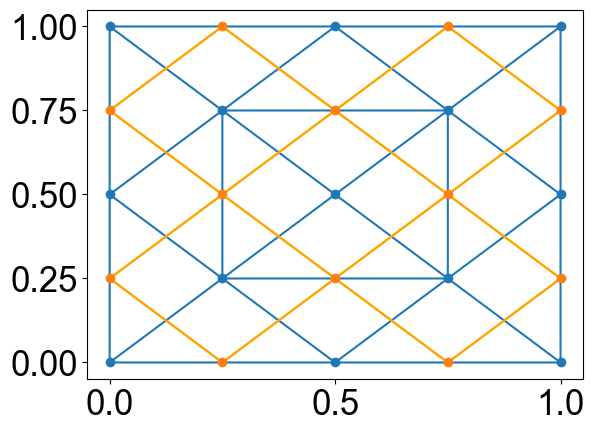

In [4]:
# Solid boundaries of plate
x_lb = 0
x_ub = R  # For simplicity
y_lb = 0
y_ub = R  # Actual parallel plate dimension
domain = [(x_lb, x_ub), (y_lb, y_ub)]
points = incom_Poi(domain, refinements=1)
HC, tri = triang_dual(points)
#HC.vertex_face_mesh(field_conversions=True)              
HC = compute_vd(HC)            
# Optionally plot
plot_dual_mesh_2D(HC, tri)

# For each vertex compute its local dual area:

Areas = []
for vp1 in HC.V:
    area = 0 
    area += d_area(vp1)
    Areas.append(area)

# Set ICs:
mass_IC(HC)  # mass IC
v_IC(HC)  # Velocity IC
P_IC(HC)  # Pressure field IC

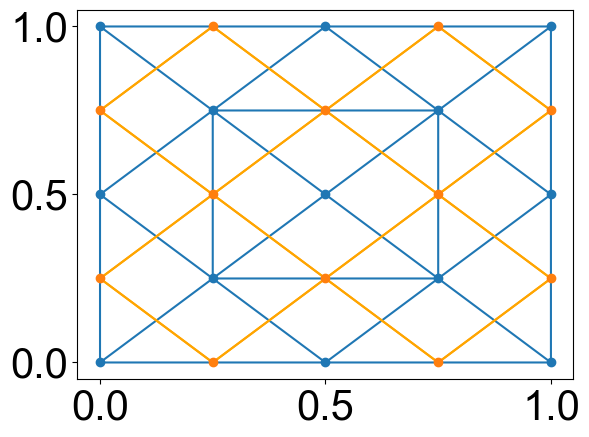

In [22]:


# Now plot something to see the effect
# Solid boundaries of plate
x_lb = 0
x_ub = R  # For simplicity
y_lb = 0
y_ub = R  # Actual parallel plate dimension
domain = [(x_lb, x_ub), (y_lb, y_ub)]
points = incom_Poi(domain, refinements=1)
HC, tri = triang_dual(points)
#HC.vertex_face_mesh(field_conversions=True)              
HC = compute_vd(HC)            
# Optionally plot
plot_dual_mesh_2D(HC, tri)

# For each vertex compute its local dual area:
import numpy as np

Areas = []
for vp1 in HC.V:
    area = 0 
    area += d_area(vp1)
    Areas.append(area)

# Set ICs:
mass_IC(HC)  # mass IC
v_IC(HC)  # Velocity IC
P_IC(HC)  # Pressure field IC

# Plot IC velocity field
p = []
u = []
for v in HC.V:
    p.append(v.x_a)
    u.append(v.u)
    
p = np.array(p)
u = np.array(u)

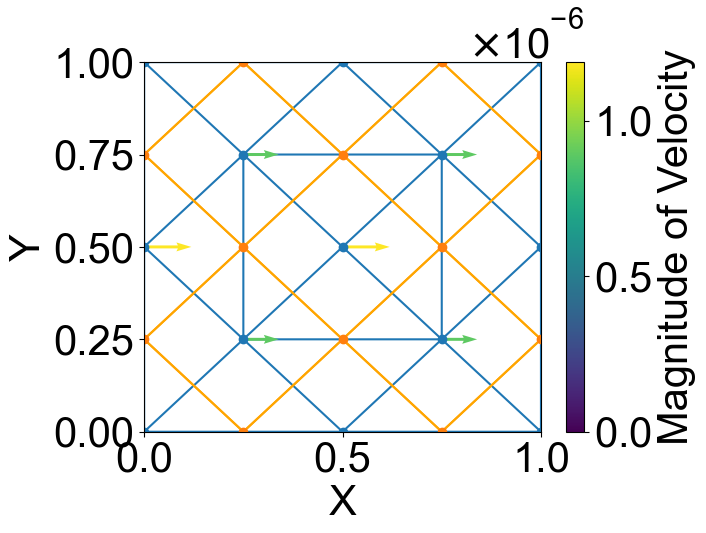

In [26]:
mpl.rcParams['font.size'] = 30
plot_discrete_field(p, u, HC, tri, scale=1e-5)

#### Mixed

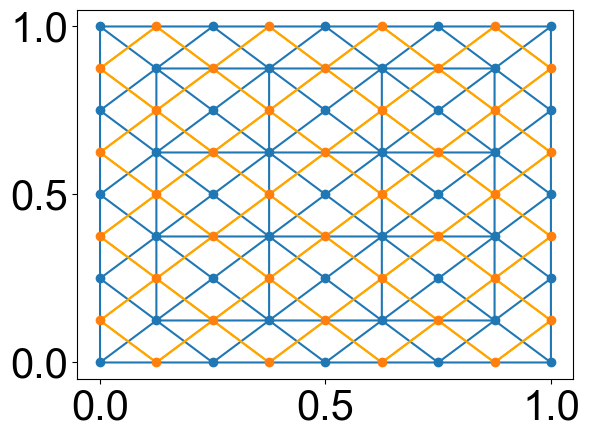

In [7]:
# Solid boundaries of plate
x_lb = 0
x_ub = R  # For simplicity
y_lb = 0
y_ub = R  # Actual parallel plate dimension
domain = [(x_lb, x_ub), (y_lb, y_ub)]
points = incom_Poi(domain, refinements=2)
HC, tri = triang_dual(points)
#HC.vertex_face_mesh(field_conversions=True)              
HC = compute_vd(HC)            
# Optionally plot
plot_dual_mesh_2D(HC, tri)

# For each vertex compute its local dual area:
import numpy as np

Areas = []
for vp1 in HC.V:
    area = 0 
    area += d_area(vp1)
    Areas.append(area)

# Set ICs:
mass_IC(HC)  # mass IC
v_IC(HC)  # Velocity IC
P_IC(HC)  # Pressure field IC

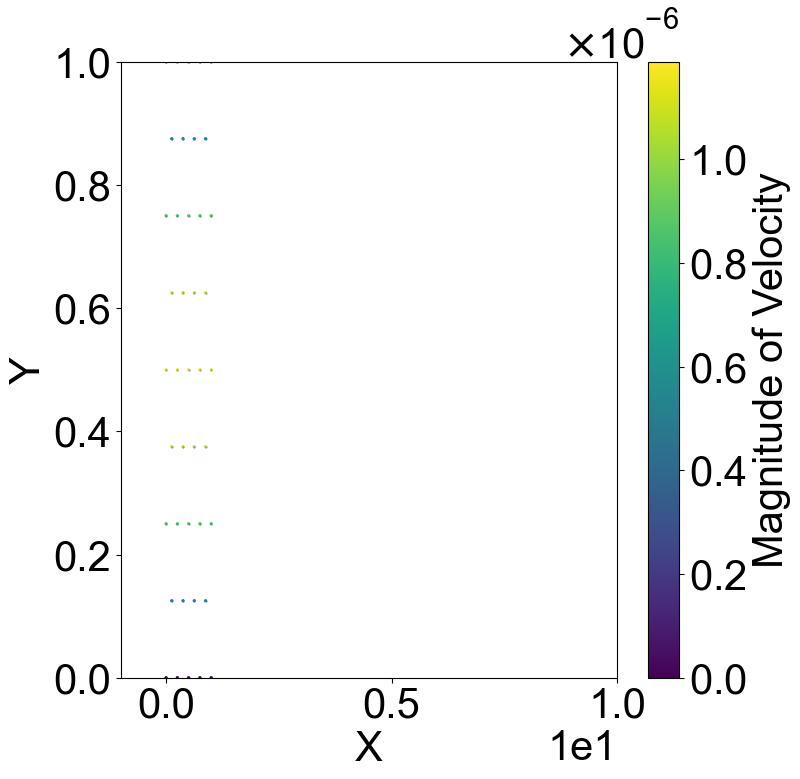

Error = 2.7087001856718755e-11


In [8]:
# Plot IC velocity field
p = []
u = []
for v in HC.V:
    p.append(v.x_a)
    u.append(v.u)
    
p = np.array(p)
u = np.array(u)
plot_field(p, u)
print(f'Error = {v_error(HC)}')

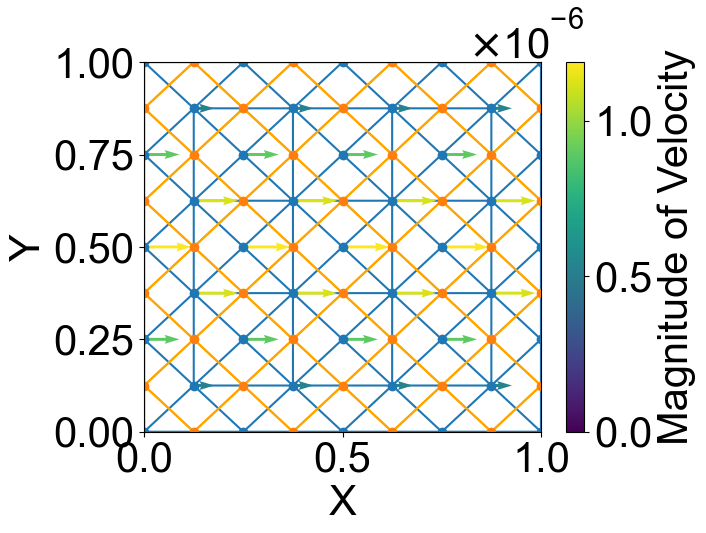

In [9]:
mpl.rcParams['font.size'] = 30
plot_discrete_field(p, u, HC, tri, scale=1e-5)

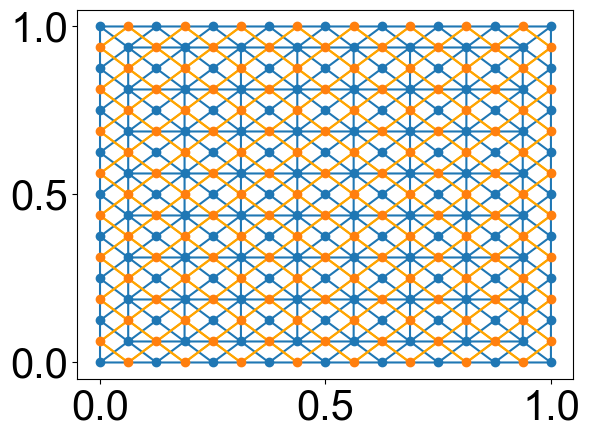

In [10]:
# Solid boundaries of plate
x_lb = 0
x_ub = R  # For simplicity
y_lb = 0
y_ub = R  # Actual parallel plate dimension
domain = [(x_lb, x_ub), (y_lb, y_ub)]
points = incom_Poi(domain, refinements=3)
HC, tri = triang_dual(points)
#HC.vertex_face_mesh(field_conversions=True)              
HC = compute_vd(HC)            
# Optionally plot
plot_dual_mesh_2D(HC, tri)

# For each vertex compute its local dual area:
import numpy as np

Areas = []
for vp1 in HC.V:
    area = 0 
    area += d_area(vp1)
    Areas.append(area)

# Set ICs:
mass_IC(HC)  # mass IC
v_IC(HC)  # Velocity IC
P_IC(HC)  # Pressure field IC

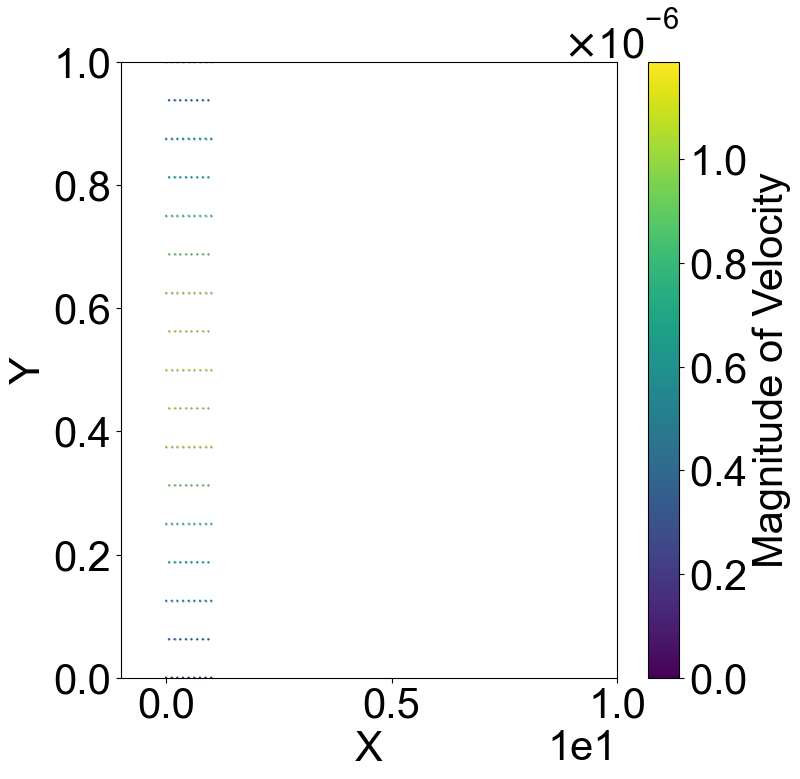

Error = 1.0239239626945316e-10


In [11]:
# Plot IC velocity field
p = []
u = []
for v in HC.V:
    p.append(v.x_a)
    u.append(v.u)
    
p = np.array(p)
u = np.array(u)
plot_field(p, u)
print(f'Error = {v_error(HC)}')

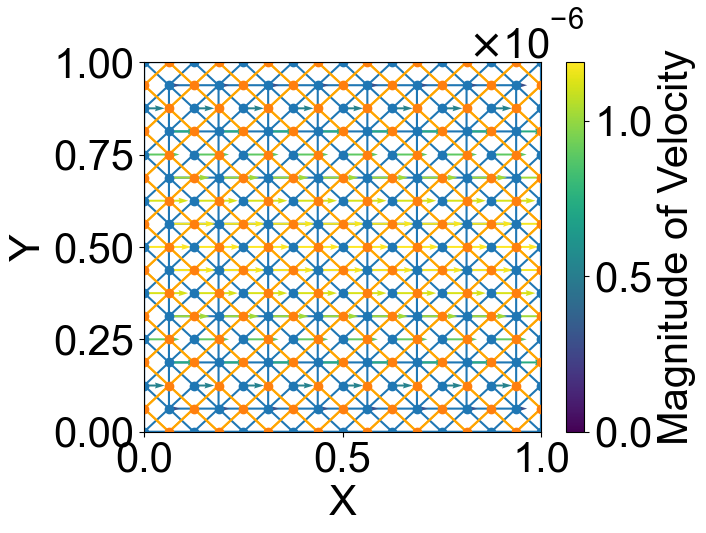

In [12]:
mpl.rcParams['font.size'] = 30
plot_discrete_field(p, u, HC, tri, scale=1e-5)

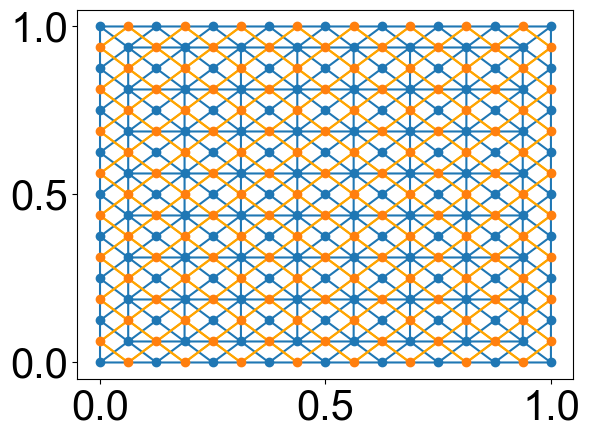

In [13]:
# Solid boundaries of plate
x_lb = 0
x_ub = R  # For simplicity
y_lb = 0
y_ub = R  # Actual parallel plate dimension
domain = [(x_lb, x_ub), (y_lb, y_ub)]
points = incom_Poi(domain, refinements=3)
HC, tri = triang_dual(points)
#HC.vertex_face_mesh(field_conversions=True)              
HC = compute_vd(HC)            
# Optionally plot
plot_dual_mesh_2D(HC, tri)

# For each vertex compute its local dual area:
import numpy as np

Areas = []
for vp1 in HC.V:
    area = 0 
    area += d_area(vp1)
    Areas.append(area)

# Set ICs:
mass_IC(HC)  # mass IC
v_IC(HC)  # Velocity IC
P_IC(HC)  # Pressure field IC

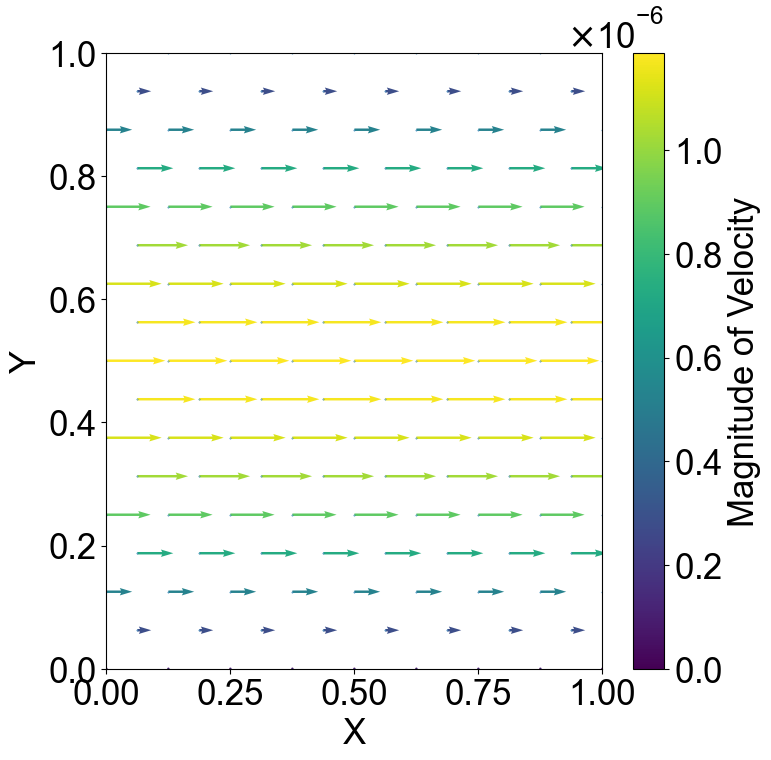

Error = 1.0239239626945316e-10


In [14]:
mpl.rcParams['font.size'] = 25
# Plot IC velocity field
p = []
u = []
for v in HC.V:
    p.append(v.x_a)
    u.append(v.u)
    
p = np.array(p)
u = np.array(u)
plot_field(p, u, xlim_lb=0, xlim_ub=1, scale=1e-5)
print(f'Error = {v_error(HC)}')

# Mesh independence

Note the results belwo are copied from notebook `2D incompressible Poiseuille flow p. vii, mesh independence.ipynb`



In [15]:
y = np.array([1.55113927e-21, 1.55113927e-21, 1.55113927e-21, 1.55113927e-21,
       1.55113927e-21, 1.55113927e-21])  # Normalized velocity

errors = np.array([[-8.45961192e-12,  1.60784489e-17],
       [-8.45961192e-12,  1.60784489e-17],
       [-8.45961192e-12,  1.60784489e-17],
       [-8.45961192e-12,  1.60784489e-17],
       [-8.45961192e-12,  1.60784489e-17],
       [-8.45961192e-12,  1.60784489e-17]], dtype=np.longdouble)

In [16]:
yp = (errors[:, 1] - np.average(errors[:, 1])) / np.shape(errors[:, 1])[0]
yp

array([5.13581319e-34, 5.13581319e-34, 5.13581319e-34, 5.13581319e-34,
       5.13581319e-34, 5.13581319e-34])

In [17]:
yu = y - np.average(y) / np.shape(y)[0]
yu

array([1.29261606e-21, 1.29261606e-21, 1.29261606e-21, 1.29261606e-21,
       1.29261606e-21, 1.29261606e-21])

In [18]:
errors[:, 0]

array([-8.45961192e-12, -8.45961192e-12, -8.45961192e-12, -8.45961192e-12,
       -8.45961192e-12, -8.45961192e-12], dtype=float64)

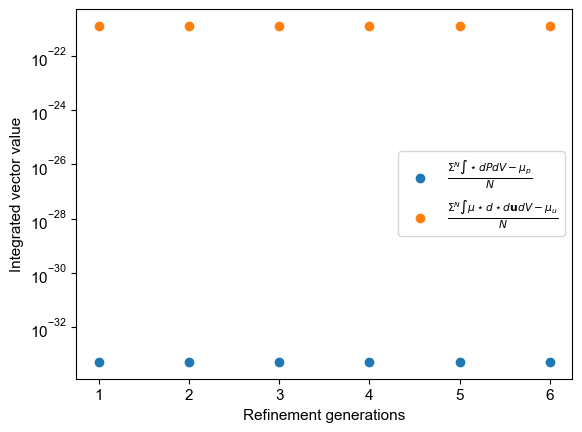

In [20]:
mpl.rcParams['font.size'] = 11
pyplot.scatter(list(range(1, 7)), yp , label=r'$\frac{\Sigma^N \int  \star dP dV - \mu_p}{N}$')
pyplot.scatter(list(range(1, 7)), yu, label=r'$\frac{\Sigma^N \int \mu \star  d  \star d \mathbf{u} dV - \mu_u}{N}$')
pyplot.yscale("log")
plt.xlabel('Refinement generations')
plt.ylabel('Integrated vector value')
pyplot.legend()
#pyplot.ylim([1e-18, 50])

# Timeline


In [107]:
import plotly.figure_factory as ff

tasks = [
    dict(Task="Milestone 1: Implement DDG incompressible fluid solvers", Start="2024-01-01", Finish="2024-12-01", Resource="Implementation"),
    dict(Task="Sub-milestone 1a: Validate integrated vector velocity Laplacian", Start="2024-06-01", Finish="2024-12-01", Resource="Validation"),
    dict(Task="Sub-milestone 1b: Validate dynamic capillary rise", Start="2024-06-01", Finish="2024-12-01", Resource="Validation"),
    dict(Task="Milestone 2: Implement DDG fluid solvers DEM solver", Start="2025-01-01", Finish="2025-12-01", Resource="Implementation"),
    dict(Task="Sub-milestone 2a: Validate dynamic particle-particle liquid bridge", Start="2025-06-01", Finish="2025-12-01", Resource="Validation"),
    dict(Task="Sub-milestone 2b: Test complex fluid-particle clusters", Start="2025-06-01", Finish="2025-12-01", Resource="Validation"),
    dict(Task="Milestone 3: Implement compressible fluid solvers", Start="2026-01-01", Finish="2026-08-01", Resource="Implementation"),
    dict(Task="Sub-milestone 3a: Validate with Venturi tube test case", Start="2026-06-01", Finish="2026-08-01", Resource="Validation"),
    dict(Task="Milestone 4: Test scalability benchmarks", Start="2026-08-01", Finish="2026-12-01", Resource="Scalability"),
]

colors = {
    "Implementation": "rgb(58, 200, 225)",
    "Validation": "rgb(107, 127, 135)",
    "Scalability": "rgb(255, 153, 51)"
}

fig = ff.create_gantt(tasks, colors=colors, index_col="Resource", show_colorbar=True, group_tasks=True, showgrid_x=True, title="Project Timeline")
fig.show()


In [1]:
import plotly.figure_factory as ff

tasks = [
    dict(Task="Milestone 1: Implement DDG incompressible fluid solvers", Start="2024-01-01", Finish="2024-12-01", Resource="Implementation"),
    dict(Task="Sub-milestone 1a: Validate integrated vector velocity Laplacian", Start="2024-06-01", Finish="2024-12-01", Resource="Validation"),
    dict(Task="Sub-milestone 1b: Validate dynamic capillary rise", Start="2024-06-01", Finish="2024-12-01", Resource="Validation"),
    dict(Task="Milestone 2: Implement DDG fluid solvers DEM solver", Start="2025-01-01", Finish="2025-12-01", Resource="Implementation"),
    dict(Task="Sub-milestone 2a: Coupling libraries for DDG fluid solvers and DEM", Start="2025-01-01", Finish="2025-10-01", Resource="Implementation"),
    dict(Task="Sub-milestone 2b: Test complex fluid-particle clusters", Start="2025-10-01", Finish="2025-12-01", Resource="Validation"),
    dict(Task="Milestone 3: Implement compressible fluid solvers", Start="2026-01-01", Finish="2026-06-01", Resource="Implementation"),
    dict(Task="Sub-milestone 3a: Validate with Sod shock tube test case", Start="2026-06-01", Finish="2026-08-01", Resource="Validation"),
    dict(Task="Milestone 4: Test scalability benchmarks", Start="2026-08-01", Finish="2026-12-01", Resource="Scalability"),
]

colors = {
    "Implementation": "rgb(58, 200, 225)",
    "Validation": "rgb(107, 127, 135)",
    "Scalability": "rgb(255, 153, 51)"
}

fig = ff.create_gantt(tasks, colors=colors, index_col="Resource", show_colorbar=True, group_tasks=True, showgrid_x=True, title="Project Timeline")
fig.show()


Explain DDG

In [126]:
mpl.rcParams['font.size'] = 25
def plot_discrete_field_ex(p, u, HC, tri, xlim_lb=0, xlim_ub=1, scale=1e-6):
    """
    Plot the velocity fields using points `p` and
    associated velocities `u`.
    
    vfac adjusts the arrow length to account for very low velocities in the field
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Find the dual points
    dual_points = []
    for vd in HC.Vd:
        #print('-')
        #print(vd.x_a)
        dual_points.append(vd.x_a)
        #for vdn in vd.v
    dual_points = np.array(dual_points)
    
    for v in HC.V:
        # "Connect duals":
        for v2 in v.nn:
            v1vdv2vd = v.vd.intersection(v2.vd)  # Cardinality always 1 or 2?
            if len(v1vdv2vd) == 1:
                continue
            v1vdv2vd = list(v1vdv2vd)
            x = [v1vdv2vd[0].x[0], v1vdv2vd[1].x[0]]
            y = [v1vdv2vd[0].x[1], v1vdv2vd[1].x[1]]
            plt.plot(x, y, color='orange')

        for vd in v.vd:
            x = [v.x[0], vd.x[0]]
            y = [v.x[1], vd.x[1]]
            #plt.plot(x, y, '--', color='tab:green')
    plt.triplot(points[:,0], points[:,1], tri.simplices, color='tab:blue')
    plt.plot(points[:,0], points[:,1],  'o', color='tab:blue')
    plt.plot(dual_points[:,0], dual_points[:,1], 'o', color='tab:orange')
    
    ## Velocity
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize

    positions = p
    velocities = u

    # Separate the positions and velocities into x, y, u, and v arrays
    x, y = positions[:, 0], positions[:, 1]
    u, v = velocities[:, 0], velocities[:, 1]

    # Calculate the magnitude of the velocity vectors
    magnitude = np.sqrt(u**2 + v**2)  # Should be around 0.1
    
    # Set the normalization range for the colors of the arrows based on the actual magnitudes
    norm = Normalize(vmin=magnitude.min(), vmax=magnitude.max())

    #plt.figure(figsize=(8, 8))
    quiver_plot = plt.quiver(x, y, u, v, magnitude, norm=norm, cmap='viridis', scale=scale)
    plt.scatter(x, y, s=0.1)
    #plt.colorbar(label='Magnitude of Velocity')
    
    def fmt(x, pos):
        a, b = '{:.2e}'.format(x).split('e')
        b = int(b)
        return r'${} \times 10^{{{}}}$'.format(a, b)
    
    #cbar = plt.colorbar(quiver_plot, format=ticker.FuncFormatter(fmt))
    cbar = plt.colorbar(quiver_plot)
    cbar.formatter.set_powerlimits((0, 0))
    cbar.formatter.set_useMathText(True)
    cbar.set_label('Magnitude of Velocity')
    #plt.title('Quiver Plot from Position Points and Velocity Vectors')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(xlim_lb, xlim_ub)
    plt.ylim(0, 1)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.show()

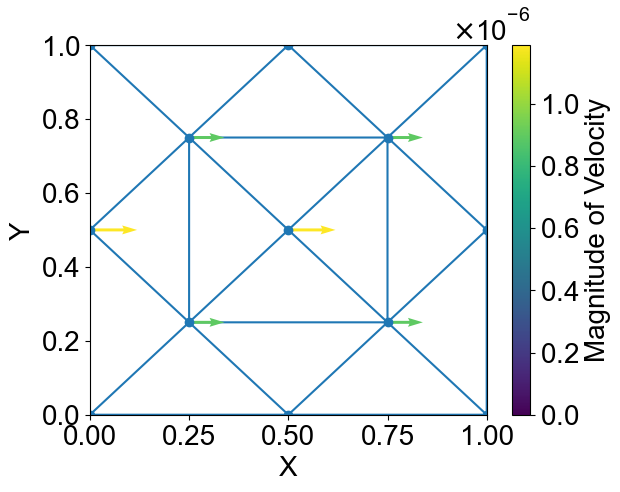

In [123]:
mpl.rcParams['font.size'] = 20
plot_discrete_field_ex(p, u, HC, tri, scale=1e-5)

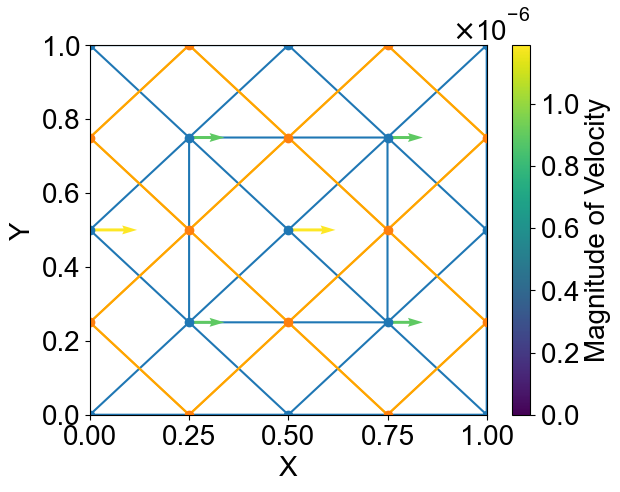

In [127]:
mpl.rcParams['font.size'] = 20
plot_discrete_field_ex(p, u, HC, tri, scale=1e-5)